In [1]:
import os 
os.getcwd()

'C:\\Users\\HP\\ml  batch -p\\test'

In [111]:
# You have to apply All Feature Enginnering work step by step :
# StandardScaler,
# MinMaxScaler,
# All type Encoding ,
# Column Transformer,
# Outlier Hnadling ,
# CCA  if there are missing data

In [112]:
# apply missing cca 
import pandas as pd 
import numpy as np
df =  pd.read_csv('C:\\Users\\HP\\ml  batch -p\\test\\ecommerce_customer_churn_dataset - ecommerce_customer_churn_dataset.csv')
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [113]:
df.isnull().mean() * 100


Age                               4.990
Gender                            0.000
Country                           0.000
City                              0.000
Membership_Years                  0.000
Login_Frequency                   0.000
Session_Duration_Avg              6.798
Pages_Per_Session                 6.000
Cart_Abandonment_Rate             0.000
Wishlist_Items                    8.000
Total_Purchases                   0.000
Average_Order_Value               0.000
Days_Since_Last_Purchase          6.000
Discount_Usage_Rate               7.000
Returns_Rate                      8.982
Email_Open_Rate                   5.056
Customer_Service_Calls            0.336
Product_Reviews_Written           7.000
Social_Media_Engagement_Score    12.000
Mobile_App_Usage                 10.000
Payment_Method_Diversity          5.000
Lifetime_Value                    0.000
Credit_Balance                   11.000
Churned                           0.000
Signup_Quarter                    0.000


In [114]:
cat  =  [var for var in df.columns if df[var].isnull().mean()<0.05 and df[var].isnull().mean()>0]
cat

['Age', 'Customer_Service_Calls']

In [115]:
len(df[cat].dropna())/len(df[cat])    # we not drop because data less than 95%  

0.94692

In [116]:
# so  we fill missing value
num =  df.select_dtypes(include=['number']).columns.to_list()
cat =   df.select_dtypes(include=['object','category']).columns.to_list()
cat

['Gender', 'Country', 'City', 'Signup_Quarter']

In [117]:
from  sklearn.impute import SimpleImputer
si =  SimpleImputer(strategy='mean')
df[num] = si.fit_transform(df[num])
si2 =  SimpleImputer(strategy ='most_frequent')
df[cat] = si2.fit_transform(df[cat])
df.isnull().mean()*100

Age                              0.0
Gender                           0.0
Country                          0.0
City                             0.0
Membership_Years                 0.0
Login_Frequency                  0.0
Session_Duration_Avg             0.0
Pages_Per_Session                0.0
Cart_Abandonment_Rate            0.0
Wishlist_Items                   0.0
Total_Purchases                  0.0
Average_Order_Value              0.0
Days_Since_Last_Purchase         0.0
Discount_Usage_Rate              0.0
Returns_Rate                     0.0
Email_Open_Rate                  0.0
Customer_Service_Calls           0.0
Product_Reviews_Written          0.0
Social_Media_Engagement_Score    0.0
Mobile_App_Usage                 0.0
Payment_Method_Diversity         0.0
Lifetime_Value                   0.0
Credit_Balance                   0.0
Churned                          0.0
Signup_Quarter                   0.0
dtype: float64

In [118]:
import matplotlib.pyplot as plt  
import  seaborn as sns 
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

<Axes: xlabel='Age'>

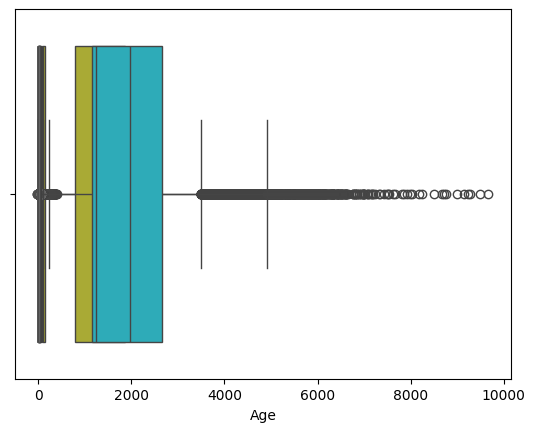

In [119]:
sns.boxplot(x = df['Age'])
sns.boxplot(x = df['Membership_Years'])
sns.boxplot(x = df['Login_Frequency'])
sns.boxplot(x = df['Session_Duration_Avg'])
sns.boxplot(x = df['Pages_Per_Session'])
sns.boxplot(x = df['Cart_Abandonment_Rate'])
sns.boxplot(x = df['Wishlist_Items'])
sns.boxplot(x = df['Total_Purchases'])
sns.boxplot(x=df['Average_Order_Value'])
sns.boxplot(x=df['Days_Since_Last_Purchase'])
sns.boxplot(x=df['Discount_Usage_Rate'])
sns.boxplot(x=df['Returns_Rate'])
sns.boxplot(x=df['Email_Open_Rate'])
sns.boxplot(x=df['Customer_Service_Calls'])
sns.boxplot(x=df['Product_Reviews_Written'])
sns.boxplot(x=df['Social_Media_Engagement_Score'])
sns.boxplot(x=df['Mobile_App_Usage'])
sns.boxplot(x=df['Payment_Method_Diversity'])
sns.boxplot(x=df['Lifetime_Value'])
sns.boxplot(x=df['Credit_Balance'])



In [120]:
per_25_age  = df['Age'].quantile(0.25)
per_75_age = df['Age'].quantile(0.75)

per_25_Membership_Years  = df['Membership_Years'].quantile(0.25)
per_75_Membership_Years = df['Membership_Years'].quantile(0.75)

per_25_Login_Frequency  = df['Login_Frequency'].quantile(0.25)
per_75_Login_Frequency = df['Login_Frequency'].quantile(0.75)

per_25_Session_Duration_Avg  = df['Session_Duration_Avg'].quantile(0.25)
per_75_Session_Duration_Avg = df['Session_Duration_Avg'].quantile(0.75)

per_25_Pages_Per_Session  = df['Pages_Per_Session'].quantile(0.25)
per_75_Pages_Per_Session = df['Pages_Per_Session'].quantile(0.75)

per_25_Cart_Abandonment_Rate  = df['Cart_Abandonment_Rate'].quantile(0.25)
per_75_Cart_Abandonment_Rate = df['Cart_Abandonment_Rate'].quantile(0.75)

per_25_Wishlist_Items  = df['Wishlist_Items'].quantile(0.25)
per_75_Wishlist_Items = df['Wishlist_Items'].quantile(0.75)

per_25_Total_Purchases  = df['Total_Purchases'].quantile(0.25)
per_75_Total_Purchases = df['Total_Purchases'].quantile(0.75)

per_25_Average_Order_Value  = df['Average_Order_Value'].quantile(0.25)
per_75_Average_Order_Value = df['Average_Order_Value'].quantile(0.75)

per_25_Days_Since_Last_Purchase  = df['Days_Since_Last_Purchase'].quantile(0.25)
per_75_Days_Since_Last_Purchase = df['Days_Since_Last_Purchase'].quantile(0.75)

per_25_Discount_Usage_Rate  = df['Discount_Usage_Rate'].quantile(0.25)
per_75_Discount_Usage_Rate = df['Discount_Usage_Rate'].quantile(0.75)

per_25_Returns_Rate  = df['Returns_Rate'].quantile(0.25)
per_75_Returns_Rate = df['Returns_Rate'].quantile(0.75)

per_25_Email_Open_Rate  = df['Email_Open_Rate'].quantile(0.25)
per_75_Email_Open_Rate = df['Email_Open_Rate'].quantile(0.75)

per_25_Customer_Service_Calls  = df['Customer_Service_Calls'].quantile(0.25)
per_75_Customer_Service_Calls = df['Customer_Service_Calls'].quantile(0.75)

per_25_Product_Reviews_Written  = df['Product_Reviews_Written'].quantile(0.25)
per_75_Product_Reviews_Written = df['Product_Reviews_Written'].quantile(0.75)

per_25_Social_Media_Engagement_Score  = df['Social_Media_Engagement_Score'].quantile(0.25)
per_75_Social_Media_Engagement_Score = df['Social_Media_Engagement_Score'].quantile(0.75)

per_25_Mobile_App_Usage  = df['Mobile_App_Usage'].quantile(0.25)
per_75_Mobile_App_Usage = df['Mobile_App_Usage'].quantile(0.75)

per_25_Payment_Method_Diversity = df['Payment_Method_Diversity'].quantile(0.25)
per_75_Payment_Method_Diversity = df['Payment_Method_Diversity'].quantile(0.75)

per_25_Lifetime_Value = df['Lifetime_Value'].quantile(0.25)
per_75_Lifetime_Value = df['Lifetime_Value'].quantile(0.75)

per_25_Credit_Balance = df['Credit_Balance'].quantile(0.25)
per_75_Credit_Balance = df['Credit_Balance'].quantile(0.75)

In [154]:
IQR1  = per_75_age - per_25_age
IQR2  = per_75_Membership_Years - per_25_Membership_Years
IQR3  = per_75_Login_Frequency - per_25_Login_Frequency
IQR4  = per_75_Session_Duration_Avg - per_25_Session_Duration_Avg
IQR5  = per_75_Pages_Per_Session - per_25_Pages_Per_Session
IQR6  = per_75_Cart_Abandonment_Rate - per_25_Cart_Abandonment_Rate
IQR7  = per_75_Wishlist_Items - per_25_Wishlist_Items
IQR8  = per_75_Total_Purchases - per_25_Total_Purchases
IQR9  = per_75_Average_Order_Value - per_25_Average_Order_Value
IQR10 = per_75_Days_Since_Last_Purchase - per_25_Days_Since_Last_Purchase
IQR11 = per_75_Discount_Usage_Rate - per_25_Discount_Usage_Rate
IQR12 = per_75_Returns_Rate - per_25_Returns_Rate
IQR13 = per_75_Email_Open_Rate - per_25_Email_Open_Rate
IQR14 = per_75_Customer_Service_Calls - per_25_Customer_Service_Calls
IQR15 = per_75_Product_Reviews_Written - per_25_Product_Reviews_Written
IQR16 = per_75_Social_Media_Engagement_Score - per_25_Social_Media_Engagement_Score
IQR17 = per_75_Mobile_App_Usage - per_25_Mobile_App_Usage
IQR18 = per_75_Payment_Method_Diversity - per_25_Payment_Method_Diversity
IQR19 = per_75_Lifetime_Value - per_25_Lifetime_Value
IQR20 = per_75_Credit_Balance - per_25_Credit_Balance


In [155]:
upper_limit_age = per_75_age + 1.5 * IQR1
upper_limit_Membership_Years = per_75_Membership_Years + 1.5 * IQR2
upper_limit_Login_Frequency = per_75_Login_Frequency + 1.5 * IQR3
upper_limit_Session_Duration_Avg = per_75_Session_Duration_Avg + 1.5 * IQR4
upper_limit_Pages_Per_Session = per_75_Pages_Per_Session + 1.5 * IQR5
upper_limit_Cart_Abandonment_Rate = per_75_Cart_Abandonment_Rate + 1.5 * IQR6
upper_limit_Wishlist_Items = per_75_Wishlist_Items + 1.5 * IQR7
upper_limit_Total_Purchases = per_75_Total_Purchases + 1.5 * IQR8
upper_limit_Average_Order_Value = per_75_Average_Order_Value + 1.5 * IQR9
upper_limit_Days_Since_Last_Purchase = per_75_Days_Since_Last_Purchase + 1.5 * IQR10
upper_limit_Discount_Usage_Rate = per_75_Discount_Usage_Rate + 1.5 * IQR11
upper_limit_Returns_Rate = per_75_Returns_Rate + 1.5 * IQR12
upper_limit_Email_Open_Rate = per_75_Email_Open_Rate + 1.5 * IQR13
upper_limit_Customer_Service_Calls = per_75_Customer_Service_Calls + 1.5 * IQR14
upper_limit_Product_Reviews_Written = per_75_Product_Reviews_Written + 1.5 * IQR15
upper_limit_Social_Media_Engagement_Score = per_75_Social_Media_Engagement_Score + 1.5 * IQR16
upper_limit_Mobile_App_Usage = per_75_Mobile_App_Usage + 1.5 * IQR17
upper_limit_Payment_Method_Diversity = per_75_Payment_Method_Diversity + 1.5 * IQR18
upper_limit_Lifetime_Value = per_75_Lifetime_Value + 1.5 * IQR19
upper_limit_Credit_Balance = per_75_Credit_Balance + 1.5 * IQR20

In [156]:
lower_limit_age = per_25_age - 1.5 * IQR1
lower_limit_Membership_Years = per_25_Membership_Years - 1.5 * IQR2
lower_limit_Login_Frequency = per_25_Login_Frequency - 1.5 * IQR3
lower_limit_Session_Duration_Avg = per_25_Session_Duration_Avg - 1.5 * IQR4
lower_limit_Pages_Per_Session = per_25_Pages_Per_Session - 1.5 * IQR5
lower_limit_Cart_Abandonment_Rate = per_25_Cart_Abandonment_Rate - 1.5 * IQR6
lower_limit_Wishlist_Items = per_25_Wishlist_Items - 1.5 * IQR7
lower_limit_Total_Purchases = per_25_Total_Purchases - 1.5 * IQR8
lower_limit_Average_Order_Value = per_25_Average_Order_Value - 1.5 * IQR9
lower_limit_Days_Since_Last_Purchase = per_25_Days_Since_Last_Purchase - 1.5 * IQR10
lower_limit_Discount_Usage_Rate = per_25_Discount_Usage_Rate - 1.5 * IQR11
lower_limit_Returns_Rate = per_25_Returns_Rate - 1.5 * IQR12
lower_limit_Email_Open_Rate = per_25_Email_Open_Rate - 1.5 * IQR13
lower_limit_Customer_Service_Calls = per_25_Customer_Service_Calls - 1.5 * IQR14
lower_limit_Product_Reviews_Written = per_25_Product_Reviews_Written - 1.5 * IQR15
lower_limit_Social_Media_Engagement_Score = per_25_Social_Media_Engagement_Score - 1.5 * IQR16
lower_limit_Mobile_App_Usage = per_25_Mobile_App_Usage - 1.5 * IQR17
lower_limit_Payment_Method_Diversity = per_25_Payment_Method_Diversity - 1.5 * IQR18
lower_limit_Lifetime_Value = per_25_Lifetime_Value - 1.5 * IQR19
lower_limit_Credit_Balance = per_25_Credit_Balance - 1.5 * IQR20

In [157]:
# capping  
df['Age'] = np.where(df['Age']>upper_limit_age,upper_limit_age,np.where(df['Age']<lower_limit_age,lower_limit_age,df['Age']))

<Axes: xlabel='Age'>

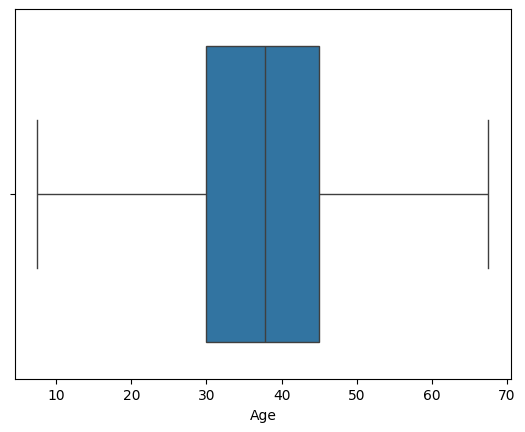

In [158]:
sns.boxplot(x=df['Age'])

In [218]:
# remove all  outlier 
df['Membership_Years'] = np.where(
    df['Membership_Years'] > upper_limit_Membership_Years, upper_limit_Membership_Years,
    np.where(df['Membership_Years'] < lower_limit_Membership_Years, lower_limit_Membership_Years,df['Membership_Years'])
)

df['Login_Frequency'] = np.where(
    df['Login_Frequency'] > upper_limit_Login_Frequency, upper_limit_Login_Frequency,
    np.where(df['Login_Frequency'] < lower_limit_Login_Frequency, lower_limit_Login_Frequency,df['Login_Frequency'])
)

df['Session_Duration_Avg'] = np.where(
    df['Session_Duration_Avg'] > upper_limit_Session_Duration_Avg, upper_limit_Session_Duration_Avg,
    np.where(df['Session_Duration_Avg'] < lower_limit_Session_Duration_Avg, lower_limit_Session_Duration_Avg,df['Session_Duration_Avg'])
)

df['Pages_Per_Session'] = np.where(
    df['Pages_Per_Session'] > upper_limit_Pages_Per_Session, upper_limit_Pages_Per_Session,
    np.where(df['Pages_Per_Session'] < lower_limit_Pages_Per_Session, lower_limit_Pages_Per_Session,df['Pages_Per_Session'])
)

df['Cart_Abandonment_Rate'] = np.where(
    df['Cart_Abandonment_Rate'] > upper_limit_Cart_Abandonment_Rate, upper_limit_Cart_Abandonment_Rate,
    np.where(df['Cart_Abandonment_Rate'] < lower_limit_Cart_Abandonment_Rate, lower_limit_Cart_Abandonment_Rate,df['Cart_Abandonment_Rate'])
)

df['Wishlist_Items'] = np.where(
    df['Wishlist_Items'] > upper_limit_Wishlist_Items, upper_limit_Wishlist_Items,
    np.where(df['Wishlist_Items'] < lower_limit_Wishlist_Items, lower_limit_Wishlist_Items,df['Wishlist_Items'])
)

df['Total_Purchases'] = np.where(
    df['Total_Purchases'] > upper_limit_Total_Purchases, upper_limit_Total_Purchases,
    np.where(df['Total_Purchases'] < lower_limit_Total_Purchases, lower_limit_Total_Purchases,df['Total_Purchases'])
)

df['Average_Order_Value'] = np.where(
    df['Average_Order_Value'] > upper_limit_Average_Order_Value, upper_limit_Average_Order_Value,
    np.where(df['Average_Order_Value'] < lower_limit_Average_Order_Value, lower_limit_Average_Order_Value,df['Average_Order_Value'])
)

df['Days_Since_Last_Purchase'] = np.where(
    df['Days_Since_Last_Purchase'] > upper_limit_Days_Since_Last_Purchase, upper_limit_Days_Since_Last_Purchase,
    np.where(df['Days_Since_Last_Purchase'] < lower_limit_Days_Since_Last_Purchase, lower_limit_Days_Since_Last_Purchase,df['Days_Since_Last_Purchase'])
)

df['Discount_Usage_Rate'] = np.where(
    df['Discount_Usage_Rate'] > upper_limit_Discount_Usage_Rate, upper_limit_Discount_Usage_Rate,
    np.where(df['Discount_Usage_Rate'] < lower_limit_Discount_Usage_Rate, lower_limit_Discount_Usage_Rate,df['Discount_Usage_Rate'])
)

df['Returns_Rate'] = np.where(
    df['Returns_Rate'] > upper_limit_Returns_Rate, upper_limit_Returns_Rate,
    np.where(df['Returns_Rate'] < lower_limit_Returns_Rate, lower_limit_Returns_Rate,df['Returns_Rate'])
)

df['Email_Open_Rate'] = np.where(
    df['Email_Open_Rate'] > upper_limit_Email_Open_Rate, upper_limit_Email_Open_Rate,
    np.where(df['Email_Open_Rate'] < lower_limit_Email_Open_Rate, lower_limit_Email_Open_Rate,df['Email_Open_Rate'])
)

df['Customer_Service_Calls'] = np.where(
    df['Customer_Service_Calls'] > upper_limit_Customer_Service_Calls, upper_limit_Customer_Service_Calls,
    np.where(df['Customer_Service_Calls'] < lower_limit_Customer_Service_Calls, lower_limit_Customer_Service_Calls,df['Customer_Service_Calls'])
)

df['Product_Reviews_Written'] = np.where(
    df['Product_Reviews_Written'] > upper_limit_Product_Reviews_Written, upper_limit_Product_Reviews_Written,
    np.where(df['Product_Reviews_Written'] < lower_limit_Product_Reviews_Written, lower_limit_Product_Reviews_Written,df['Product_Reviews_Written'])
)

df['Social_Media_Engagement_Score'] = np.where(
    df['Social_Media_Engagement_Score'] > upper_limit_Social_Media_Engagement_Score, upper_limit_Social_Media_Engagement_Score,
    np.where(df['Social_Media_Engagement_Score'] < lower_limit_Social_Media_Engagement_Score, lower_limit_Social_Media_Engagement_Score,df['Social_Media_Engagement_Score'])
)

df['Mobile_App_Usage'] = np.where(
    df['Mobile_App_Usage'] > upper_limit_Mobile_App_Usage, upper_limit_Mobile_App_Usage,
    np.where(df['Mobile_App_Usage'] < lower_limit_Mobile_App_Usage, lower_limit_Mobile_App_Usage,df['Mobile_App_Usage'])
)

df['Payment_Method_Diversity'] = np.where(
    df['Payment_Method_Diversity'] > upper_limit_Payment_Method_Diversity, upper_limit_Payment_Method_Diversity,
    np.where(df['Payment_Method_Diversity'] < lower_limit_Payment_Method_Diversity, lower_limit_Payment_Method_Diversity,df['Payment_Method_Diversity'])
)

df['Lifetime_Value'] = np.where(
    df['Lifetime_Value'] > upper_limit_Lifetime_Value, upper_limit_Lifetime_Value,
    np.where(df['Lifetime_Value'] < lower_limit_Lifetime_Value, lower_limit_Lifetime_Value,df['Lifetime_Value'])
)

df['Credit_Balance'] = np.where(
    df['Credit_Balance'] > upper_limit_Credit_Balance, upper_limit_Credit_Balance,
    np.where(df['Credit_Balance'] < lower_limit_Credit_Balance, lower_limit_Credit_Balance,df['Credit_Balance'])
)


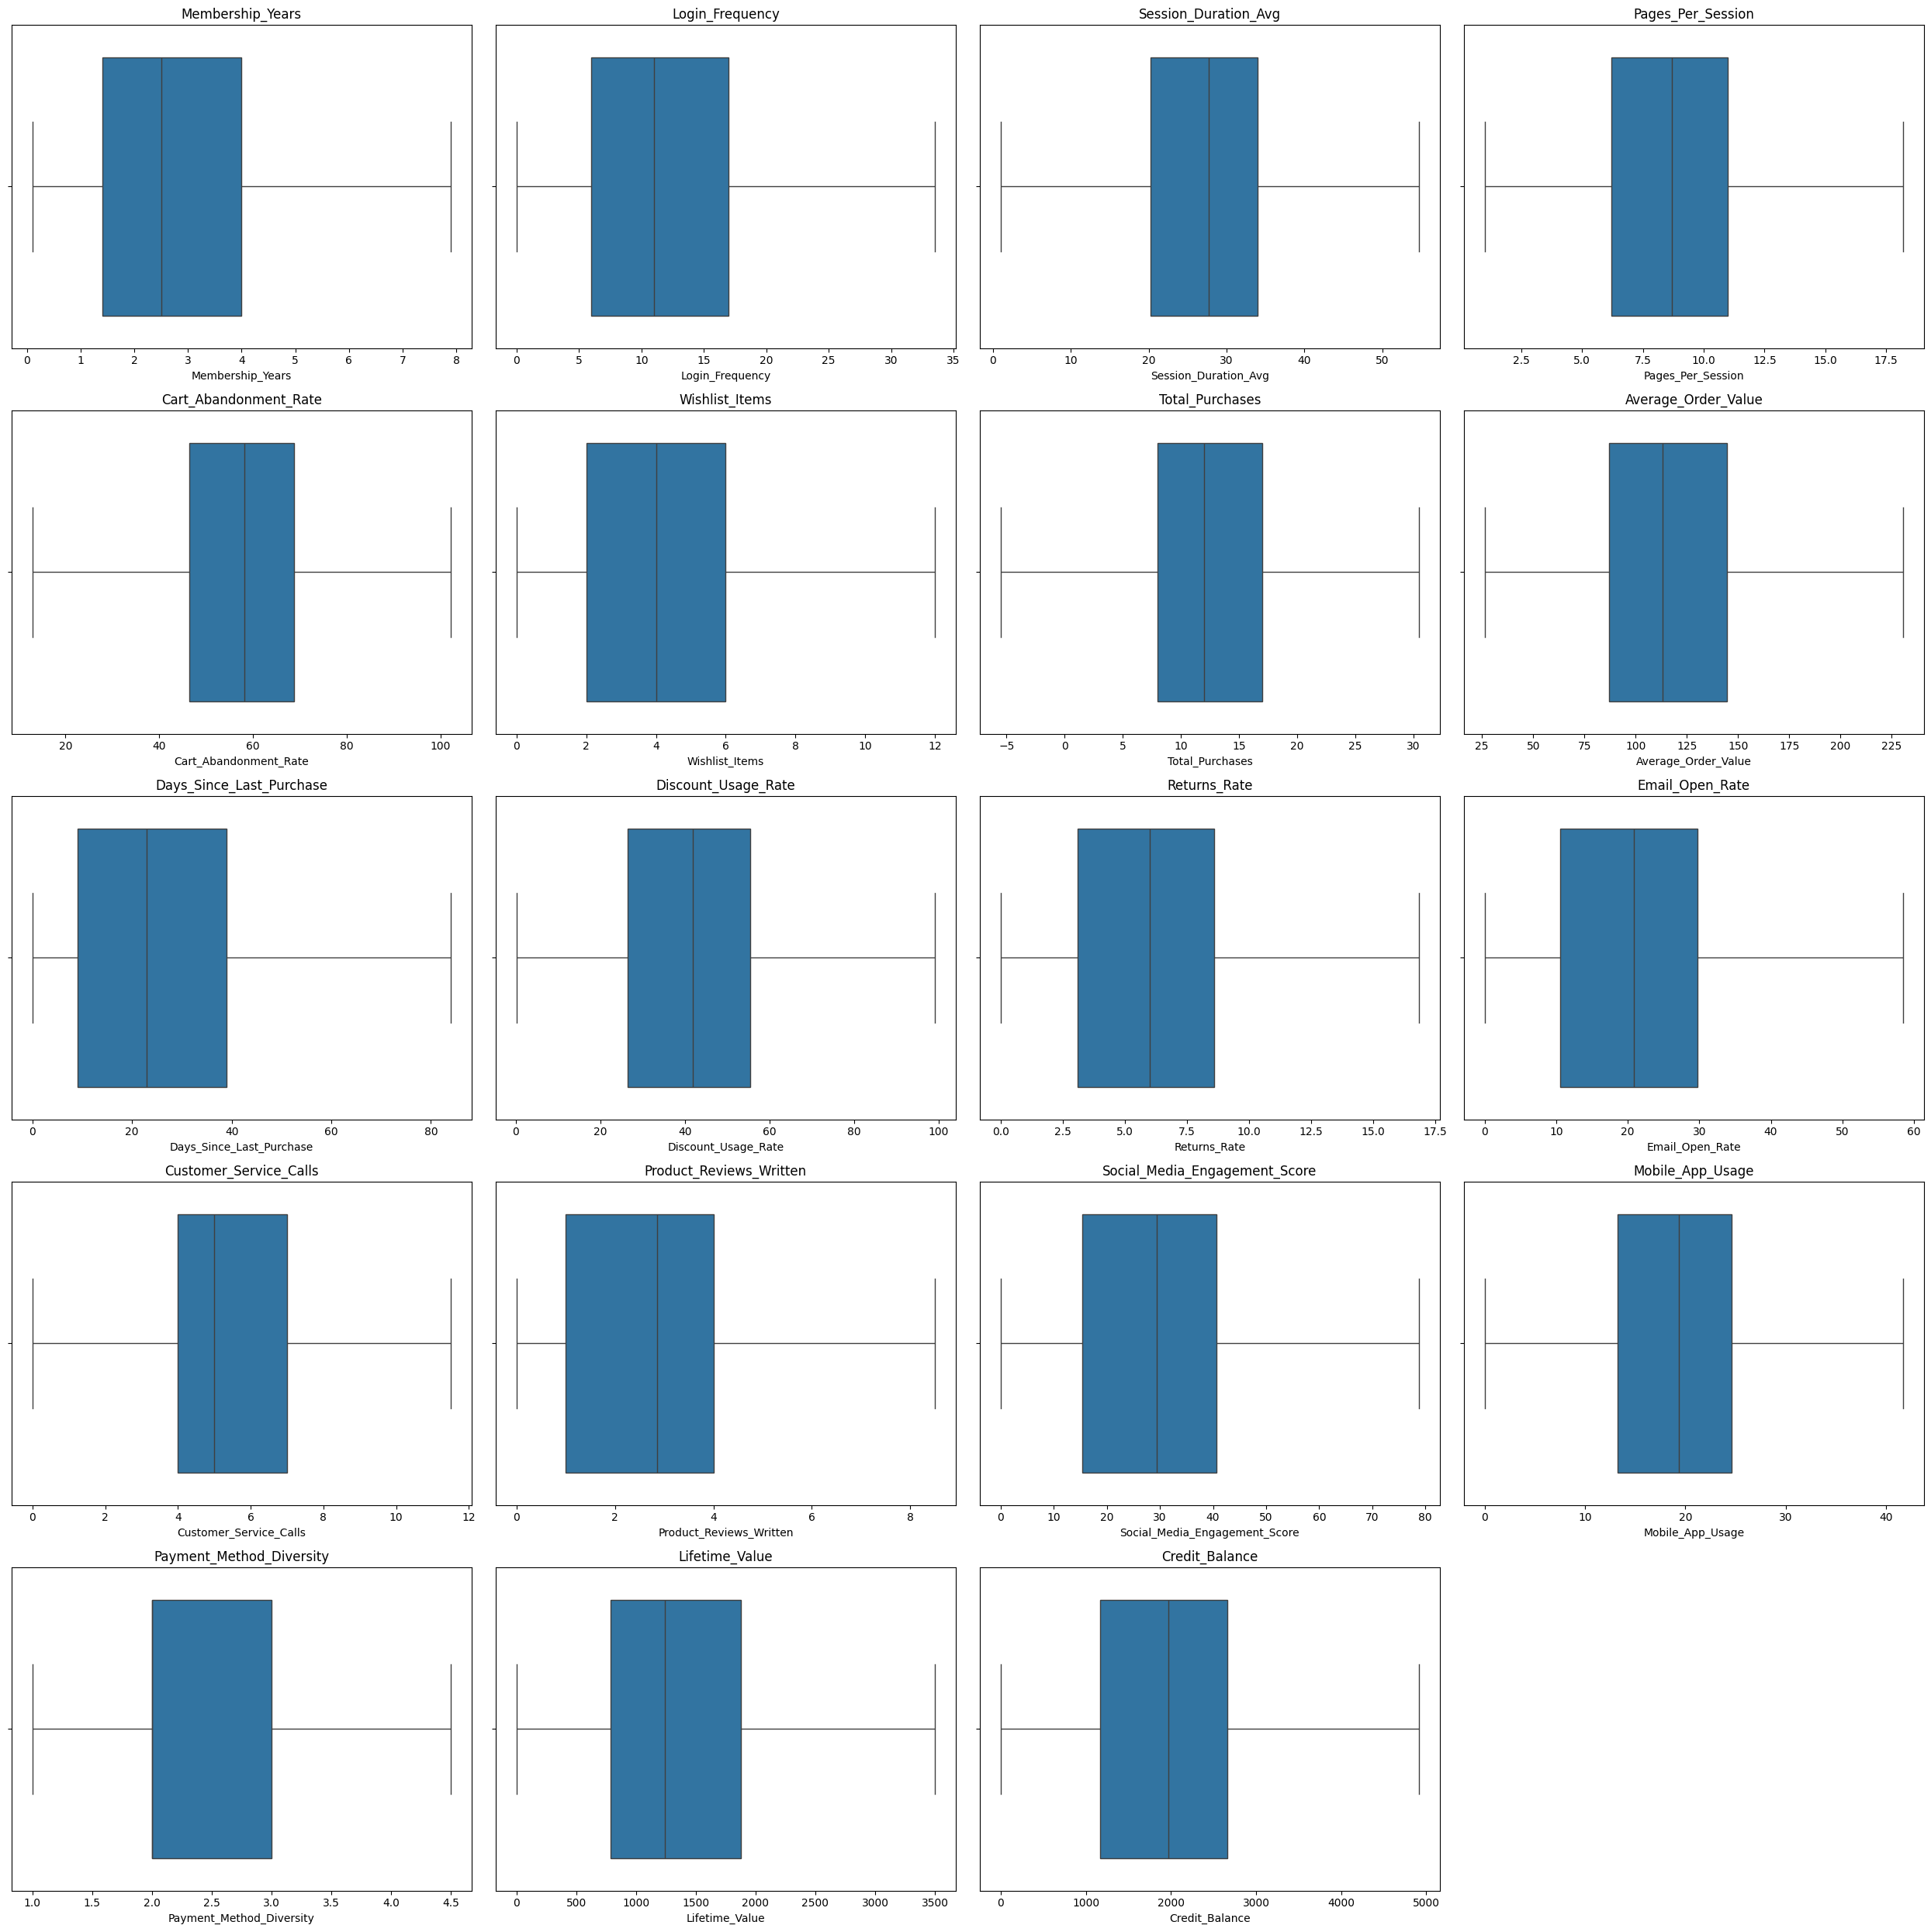

In [219]:
cols = ['Membership_Years','Login_Frequency','Session_Duration_Avg','Pages_Per_Session','Cart_Abandonment_Rate','Wishlist_Items','Total_Purchases'
        ,'Average_Order_Value','Days_Since_Last_Purchase','Discount_Usage_Rate','Returns_Rate','Email_Open_Rate','Customer_Service_Calls'
        ,'Product_Reviews_Written','Social_Media_Engagement_Score','Mobile_App_Usage','Payment_Method_Diversity','Lifetime_Value','Credit_Balance']

plt.figure(figsize=(25, 25))

for i, col in enumerate(cols, 1):
    plt.subplot(5, 4, i)   
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [220]:
# encoding  
x=df.drop(columns=['Churned'])
y=df['Churned']

from  sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

cat = x_train.select_dtypes(include=['object','category']).columns.to_list()
num =  x_train.select_dtypes(include=['number']).columns.to_list() 

In [221]:
from  sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
x_train['Gender'] = le.fit_transform(x_train['Gender'])
x_test['Gender'] = le.transform(x_test['Gender'])

In [222]:
from  sklearn.preprocessing  import  OneHotEncoder
ohe = OneHotEncoder(drop='first',sparse_output=False,dtype = np.int32)

encoded = ohe.fit_transform(x_train[['Country']])
encoded_test = ohe.transform(x_test[['Country']])

encox =pd.DataFrame(encoded,columns = ohe.get_feature_names_out(['Country']),index=x_train.index)
encox_test =pd.DataFrame(encoded_test,columns = ohe.get_feature_names_out(['Country']),index=x_test.index)

x_train = pd.concat([x_train.drop(columns=['Country']),encox],axis=1)
x_test = pd.concat([x_test.drop(columns=['Country']),encox_test],axis=1)


In [223]:
from sklearn.preprocessing  import  OrdinalEncoder
oe = OrdinalEncoder(categories=[['Q1','Q2','Q3','Q4']])

In [224]:
x_train[['Signup_Quarter']] = oe.fit_transform(x_train[['Signup_Quarter']])
x_test[['Signup_Quarter']] = oe.transform(x_test[['Signup_Quarter']])

In [225]:
enco2 = pd.get_dummies(x_train['City'],drop_first=True)
enco2 = enco2.astype(int)
enco2.index = x_train.index

enco3 = pd.get_dummies(x_test['City'],drop_first=True)
enco3 = enco3.astype(int)
enco3.index = x_test.index

x_train = pd.concat([x_train.drop(columns=['City']),enco2],axis=1)
x_test = pd.concat([x_test.drop(columns=['City']),enco3],axis=1)


In [226]:
x_train.head(10)

,Age,Gender,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,...,Ottawa,Paris,Perth,Phoenix,Sydney,Tokyo,Toronto,Toulouse,Vancouver,Yokohama
39087,25.0,0,3.7,19.0,49.1,17.1,20.7,8.000000,18.0,134.840,...,0,0,0,0,0,0,0,0,1,0
30893,33.0,0,2.5,16.0,33.7,11.0,55.8,4.298391,23.0,198.500,...,1,0,0,0,0,0,0,0,0,0
45278,32.0,0,2.1,4.0,18.4,1.0,71.8,1.000000,7.0,76.530,...,0,0,0,0,0,0,0,0,0,0
16398,48.0,1,3.2,20.0,45.5,15.9,41.7,9.000000,29.9,125.470,...,0,0,0,0,0,0,0,0,0,0
13653,35.0,1,1.6,10.0,18.7,3.1,78.8,0.000000,5.0,126.790,...,0,0,0,1,0,0,0,0,0,0
13748,64.0,0,2.1,12.0,11.0,4.1,44.2,2.000000,10.0,102.140,...,0,0,0,0,0,0,0,0,0,0
23965,44.0,0,5.9,16.0,28.9,9.5,67.1,2.000000,12.0,97.200,...,0,0,0,0,0,0,0,0,0,0
45552,40.0,0,1.6,20.0,26.8,11.0,57.2,1.000000,11.0,100.200,...,0,0,0,0,0,0,0,0,0,0
30219,51.0,1,2.7,9.0,31.5,10.8,59.7,4.000000,13.0,130.070,...,0,0,0,0,0,0,0,0,0,0
24079,56.0,0,0.8,4.0,12.8,5.6,71.4,1.000000,5.0,230.525,...,0,0,0,0,0,0,0,0,0,0


In [227]:
from  sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [228]:
from  sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
preprocessor  =  ColumnTransformer(transformers=[
                    ('tns',StandardScaler(),num)
                     ],remainder='passthrough')

In [231]:
x_train.shape

(40000, 68)

In [229]:
x_train = preprocessor.fit_transform(x_train)

array([[-1.14272611,  0.38641537,  0.95203837, ...,  0.        ,
         1.        ,  0.        ],
       [-0.42585234, -0.2306832 ,  0.56561407, ...,  0.        ,
         0.        ,  0.        ],
       [-0.51546156, -0.43638273, -0.98008311, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.51546156, -0.48780761, -0.33604262, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.20141221, -1.00205642, -0.72246692, ...,  0.        ,
         0.        ,  0.        ],
       [-0.2466339 ,  1.20921347, -0.20723452, ...,  0.        ,
         0.        ,  0.        ]], shape=(40000, 68))

In [239]:
x_train_df = pd.DataFrame(
    x_train,
    columns=preprocessor.get_feature_names_out()
)
np.round(x_train_df.describe(),2)

,tns__Age,tns__Membership_Years,tns__Login_Frequency,tns__Session_Duration_Avg,tns__Pages_Per_Session,tns__Cart_Abandonment_Rate,tns__Wishlist_Items,tns__Total_Purchases,tns__Average_Order_Value,tns__Days_Since_Last_Purchase,...,remainder__Ottawa,remainder__Paris,remainder__Perth,remainder__Phoenix,remainder__Sydney,remainder__Tokyo,remainder__Toronto,remainder__Toulouse,remainder__Vancouver,remainder__Yokohama
count,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,...,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00
mean,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,...,0.02,0.02,0.02,0.07,0.02,0.01,0.02,0.02,0.02,0.01
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,0.15,0.12,0.13,0.26,0.13,0.10,0.15,0.13,0.15,0.10
min,-2.71,-1.46,-1.50,-2.57,-2.13,-2.73,-1.45,-2.98,-2.17,-1.21,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,-0.69,-0.80,-0.72,-0.72,-0.69,-0.66,-0.77,-0.80,-0.75,-0.82,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,-0.23,-0.08,0.00,-0.00,0.06,-0.09,-0.16,-0.14,-0.22,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.65,0.59,0.69,0.62,0.63,0.72,0.59,0.65,0.60,0.46,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,2.67,2.55,2.82,2.61,2.62,2.78,2.64,2.83,2.63,2.39,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [232]:
x_test = preprocessor.transform(x_test)

In [233]:
x_test

array([[-0.42585234,  0.95208907, -0.85127501, ...,  0.        ,
         0.        ,  0.        ],
       [-0.69468   , -0.74493201,  0.82323027, ...,  0.        ,
         0.        ,  0.        ],
       [-1.23233533,  1.05493883, -0.98008311, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.76999066, -1.10490618, -1.10889121, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.0078952 , -0.89920666,  0.82323027, ...,  0.        ,
         0.        ,  0.        ],
       [-0.60507078,  0.38641537, -0.72246692, ...,  0.        ,
         0.        ,  0.        ]], shape=(10000, 68))

In [241]:
x_test_df = pd.DataFrame(
    x_test,
    columns=preprocessor.get_feature_names_out()
)
np.round(x_test_df.describe(),2)

,tns__Age,tns__Membership_Years,tns__Login_Frequency,tns__Session_Duration_Avg,tns__Pages_Per_Session,tns__Cart_Abandonment_Rate,tns__Wishlist_Items,tns__Total_Purchases,tns__Average_Order_Value,tns__Days_Since_Last_Purchase,...,remainder__Ottawa,remainder__Paris,remainder__Perth,remainder__Phoenix,remainder__Sydney,remainder__Tokyo,remainder__Toronto,remainder__Toulouse,remainder__Vancouver,remainder__Yokohama
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,...,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,-0.01,-0.01,-0.00,0.00,0.02,0.00,-0.00,0.00,0.01,-0.02,...,0.02,0.02,0.02,0.07,0.02,0.01,0.02,0.02,0.03,0.01
std,0.99,0.99,1.00,1.00,1.00,0.99,1.00,1.01,1.01,1.00,...,0.15,0.13,0.13,0.25,0.13,0.10,0.15,0.12,0.16,0.10
min,-2.71,-1.46,-1.50,-2.57,-2.13,-2.73,-1.45,-2.98,-2.12,-1.21,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,-0.69,-0.80,-0.72,-0.72,-0.69,-0.65,-0.77,-0.80,-0.75,-0.82,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,-0.23,-0.08,0.00,0.01,0.07,-0.09,-0.16,-0.13,-0.27,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.65,0.54,0.69,0.63,0.63,0.72,0.59,0.65,0.60,0.46,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,2.67,2.55,2.82,2.61,2.62,2.78,2.64,2.83,2.63,2.39,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
